# **Library and Dataset Import**

The examples uses tensorflow for NLP Modelling.

The indic-nlp-library is used for tokenization.

Dataset used is for English Hindi translation, however can be easily adopted for 10 other major Indian language as available [here](http://lotus.kuee.kyoto-u.ac.jp/WAT/indic-multilingual/) or for any other language pair (adopt as per the tensorflow tutorial references used below).

In [1]:
# Install dependencies
!pip install indic-nlp-library tqdm -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.3/40.3 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.7/7.7 MB 121.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.1/121.1 kB 13.0 MB/s eta 0:00:00


In [2]:
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from sklearn.model_selection import train_test_split
import unicodedata
import re
import numpy as np
import os
import io
import time
from tqdm.auto import tqdm

# Print TensorFlow version for compatibility check
print(f"TensorFlow version: {tf.__version__}")

# Enable mixed precision for faster training on modern GPUs (optional)
# tf.keras.mixed_precision.set_global_policy('mixed_float16')

# Set random seeds for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

TensorFlow version: 2.19.0


The dataset consists of four files: two train files and two test files. The train file consists of one file with English sentences and another with the corresponding Hindi translations, similarly for the test files. There is a dev file available as well which can be used for validation.

The train files contain 84557 translations, out of which we will be using 70,000 for training. The test files contain 1000 translations.

In [3]:
!wget "http://lotus.kuee.kyoto-u.ac.jp/WAT/indic-multilingual/indic_languages_corpus.tar.gz"

--2026-01-10 07:02:14--  http://lotus.kuee.kyoto-u.ac.jp/WAT/indic-multilingual/indic_languages_corpus.tar.gz
Resolving lotus.kuee.kyoto-u.ac.jp (lotus.kuee.kyoto-u.ac.jp)... 130.54.208.131
Connecting to lotus.kuee.kyoto-u.ac.jp (lotus.kuee.kyoto-u.ac.jp)|130.54.208.131|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 132762852 (127M) [application/x-gzip]
Saving to: ‘indic_languages_corpus.tar.gz’

indic_languages_cor 100%[===================>] 126.61M  10.7MB/s    in 13s     

2026-01-10 07:02:28 (9.61 MB/s) - ‘indic_languages_corpus.tar.gz’ saved [132762852/132762852]



In [4]:
import tarfile
with tarfile.open('indic_languages_corpus.tar.gz', 'r:gz') as tar:
    tar.extractall()
print("done!")

/tmp/ipython-input-1701468940.py:3: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall()


done!


In [5]:
#We copy the Hindi to English files for working in this example (dev.en, dev.hi, test.en, test.hi and train.en, train.hi)
%cp indic_languages_corpus/bilingual/hi-en/* .
#Clean up to avoid storing these files in the session
%rm -r indic_languages_corpus indic_languages_corpus.tar.gz

In [6]:
# Install Nirmala font which we would need for plotting later in the code
!wget "https://www.wfonts.com/download/data/2016/04/29/nirmala-ui/nirmala-ui.zip"

--2026-01-10 07:02:33--  https://www.wfonts.com/download/data/2016/04/29/nirmala-ui/nirmala-ui.zip
Resolving www.wfonts.com (www.wfonts.com)... 51.15.183.61
Connecting to www.wfonts.com (www.wfonts.com)|51.15.183.61|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2677244 (2.6M) [application/x-zip-compressed]
Saving to: ‘nirmala-ui.zip’

nirmala-ui.zip      100%[===================>]   2.55M  2.53MB/s    in 1.0s    

2026-01-10 07:02:35 (2.53 MB/s) - ‘nirmala-ui.zip’ saved [2677244/2677244]



In [7]:
from zipfile import ZipFile
with ZipFile('nirmala-ui.zip', 'r') as zipObj:
   # Extract all the contents of zip file in current directory
   zipObj.extractall()
print("done!")

done!


In [8]:
%rm nirmala-ui.* sharefonts.* nirmala.png

rm: cannot remove 'sharefonts.*': No such file or directory


In [9]:
# understanding how the training data looks like
f = open('train.hi')
w1 = f.readlines()
print(len(w1))
print(w1[0:5])
g = open('train.en')
w2 = g.readlines()
print(len(w2))
print(w2[0:5])

84557
['और उनके Sigil क्या है?\n', 'मैं मरना नहीं चाहता.\n', 'यह मुझे लगता है कि एक ही देश है.\n', 'फिर ये नन्हें बच्चों की तरह रोएँगे।\n', 'नहीं, मुझे पावर की जरुरत है !\n']
84557
['And what is their Sigil?\n', 'I do not want to die.\n', "It's the same country I think.\n", "Then they'll be crying like babies.\n", '- No, I need power up!\n']


# **Data Preperation**

Once we have loaded the dataset, we preprocess the data as follows:

Add a start and end token to each sentence.

Clean the sentences by removing special characters.

Create a word index and reverse word index (dictionaries mapping from word → id and id → word).

Pad each sentence to a maximum length.

In [10]:
# Restrict the total number of sentences to 70000
NUM_SENTENCES = 70000

In [11]:
# strip the input and output of extra unnecessary characters
# store all the cleaned input and output sentences into input_sentences[] and output_sentences[]
# tokenize the Hindi (target) sentences using the indicNLP libary class and add <sos> (start-of-sentence) and <eos> (end-of-sentence)

from indicnlp.tokenize import indic_tokenize

input_sentences = []
output_sentences = []

# Read English sentences (source language)
with open('train.en', encoding='utf-8') as f:
    for count, line in enumerate(f, 1):
        if count > NUM_SENTENCES:
            break
        input_sentence = line.rstrip().strip("\n").strip('-')
        input_sentences.append(input_sentence)

# Read Hindi sentences (target language)
with open('train.hi', encoding='utf-8') as f:
    for count, line in enumerate(f, 1):
        if count > NUM_SENTENCES:
            break
        output_sentence = line.rstrip().strip("\n").strip('-')
        # Tokenize Hindi sentences using indicNLP library
        tokens = indic_tokenize.trivial_tokenize(output_sentence)
        # Append start and end tags to the tokenized sentences
        output_sentences.append(['<sos>'] + tokens + ['<eos>'])

print(f"Input sentence type: {type(input_sentences[10])}")
print(f"Output sentence type: {type(output_sentences[10])}")

Input sentence type: <class 'str'>
Output sentence type: <class 'list'>


In [12]:
print("num samples input:", len(input_sentences))
print("num samples output:", len(output_sentences))

num samples input: 70000
num samples output: 70000


In [13]:
print(input_sentences[-1])
print(output_sentences[-1])

Her face.
['<sos>', 'उसका', 'चेहरा', '.', '<eos>']


In [14]:
# Converts the unicode file to ascii
# Remove accents etc.
def unicode_to_ascii(s):
  return ''.join(c for c in unicodedata.normalize('NFD', s)
      if unicodedata.category(c) != 'Mn')


def preprocess_sentence(w):
  w = unicode_to_ascii(w.lower().strip())

  # creating a space between a word and the punctuation following it
  # eg: "he is a boy." => "he is a boy ."
  w = re.sub(r"([?.!,¿])", r" \1 ", w)
  w = re.sub(r'[" "]+', " ", w)

  # replacing everything with space except (a-z, A-Z, ".", "?", "!", ",")
  w = re.sub(r"[^a-zA-Z?.!,¿]+", " ", w)

  w = w.strip()

  # adding a start and an end token to the sentence
  # so that the model know when to start and stop predicting.
  w = '<sos> ' + w + ' <eos>'
  return w

In [15]:
for i in range(len(input_sentences)):
   input_sentences[i] = preprocess_sentence(input_sentences[i])

print(input_sentences[8])
print(output_sentences[8])

<sos> i told her we rest on sundays . <eos>
['<sos>', 'मैं', 'रविवार', 'को', 'उसे', 'हम', 'बाकी', 'बताया', '.', '<eos>']


In [16]:
# function to tokenize, fit the words into numeric sequences and pad them with zeroes up to the size of the largest sentence of that vocabulary
# takes as input the input / output vocabulary and the padding type ('pre' / 'post'-- default: post)

# inp_lang and targ_lang is of type tokenizer.fit_on_texts;
# fit_on_texts of Tokenizer class updates internal vocabulary based on a list of texts.
# This method creates the vocabulary index based on word frequency.
# Lower integer means more frequent word (often the first few are stop words because they appear a lot).

# Note: tf.keras.preprocessing.text.Tokenizer is available in TensorFlow 2.x but may show deprecation warnings.
# For production systems, consider using tf.keras.layers.TextVectorization instead.
# We keep using Tokenizer here for educational clarity and compatibility with the existing workflow.

def tokenize(lang, pad='post'):
    """
    Tokenize and pad sequences.

    Args:
        lang: List of sentences (strings or token lists)
        pad: Padding type ('pre' or 'post')

    Returns:
        tensor: Padded integer sequences
        lang_tokenizer: Fitted tokenizer object
    """
    # Use the Keras Tokenizer (still available in TF 2.x)
    lang_tokenizer = tf.keras.preprocessing.text.Tokenizer(filters='', oov_token='<UNK>')
    lang_tokenizer.fit_on_texts(lang)

    # Convert texts to sequences
    tensor = lang_tokenizer.texts_to_sequences(lang)

    # Pad sequences to same length
    tensor = tf.keras.preprocessing.sequence.pad_sequences(tensor, padding=pad)

    return tensor, lang_tokenizer

In [17]:
# function to call the tokenize function to perform tokenizing and padding

def load_dataset(inp_lang, targ_lang):
  # creating cleaned input, output pairs
  input_tensor, inp_lang_tokenizer = tokenize(inp_lang, 'post')
  target_tensor, targ_lang_tokenizer = tokenize(targ_lang, 'post')

  return input_tensor, target_tensor, inp_lang_tokenizer, targ_lang_tokenizer

In [18]:
input_tensor, target_tensor, inp_lang, targ_lang = load_dataset(input_sentences, output_sentences)

# Calculate max_length of the target tensors
# For our project, the max_length_targ and max_length_inp are 69 and 72 respectively.

max_length_targ, max_length_inp = target_tensor.shape[1], input_tensor.shape[1]
print(max_length_targ)
print(max_length_inp)

69
72


In [19]:
# checking if the input sequences have been obtained and padded properly
print(target_tensor[9])
print(input_tensor[9])

[  2  48 204  19 204  27  40 554  80  30   6 271   9   3   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
[   2    6  107   63   64  463 6236   22    5   60    9    3    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0]


In [20]:
# Creating training and validation sets using an 80-20 split
input_tensor_train, input_tensor_val, target_tensor_train, target_tensor_val = train_test_split(input_tensor, target_tensor, test_size=0.2, random_state=42)

# Show length
print(len(input_tensor_train), len(target_tensor_train), len(input_tensor_val), len(target_tensor_val))

56000 56000 14000 14000


In [21]:
# checking if the input sequences have been obtained and padded properly
print(input_tensor_val[9])
print(target_tensor_val[9])

[   2 1513 2960  132    4    3    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0]
[   2 1333 1333   19   87    4    3    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0]


In [22]:
# a function to test if the word to index / index to word mappings have been obtained correctly.
# representative output for two sample english and hindi sentences given in the code block below

def convert(lang, tensor):
  for t in tensor:
    if t!=0:
      print ("%d ----> %s" % (t, lang.index_word[t]))
      print ("%s ----> %d" % (lang.index_word[t], lang.word_index[lang.index_word[t]]))

In [23]:
print ("Input Language; index to word mapping")
convert(inp_lang, input_tensor_train[0])
print ()
print ("Target Language; index to word mapping")
convert(targ_lang, target_tensor_train[0])

Input Language; index to word mapping
2 ----> <sos>
<sos> ----> 2
46 ----> get
get ----> 46
57 ----> out
out ----> 57
18 ----> of
of ----> 18
16 ----> that
that ----> 16
1781 ----> van
van ----> 1781
14 ----> !
! ----> 14
3 ----> <eos>
<eos> ----> 3

Target Language; index to word mapping
2 ----> <sos>
<sos> ----> 2
50 ----> -
- ----> 50
23 ----> कि
कि ----> 23
2467 ----> वैन
वैन ----> 2467
19 ----> से
से ----> 19
81 ----> बाहर
बाहर ----> 81
1543 ----> निकलो
निकलो ----> 1543
15 ----> !
! ----> 15
3 ----> <eos>
<eos> ----> 3


In [24]:
# BUFFER_SIZE stores the number of training points
BUFFER_SIZE = len(input_tensor_train)

# BATCH_SIZE is set to 64. Training and gradient descent happens in batches of 64
BATCH_SIZE = 64

# the number of batches in one epoch (also, the number of steps during training, when we go batch by batch)
steps_per_epoch = BUFFER_SIZE // BATCH_SIZE

# the length of the embedded vector
embedding_dim = 256

# number of GRU units
units = 1024

# getting the size of the input and output vocabularies (add 1 for padding token at index 0)
vocab_inp_size = len(inp_lang.word_index) + 1
vocab_tar_size = len(targ_lang.word_index) + 1

# Create training dataset with optimized data pipeline
# - shuffle: randomize the order of samples
# - batch: group samples into batches
# - prefetch: prepare next batch while GPU processes current batch (improves throughput)
dataset = tf.data.Dataset.from_tensor_slices((input_tensor_train, target_tensor_train))
dataset = dataset.shuffle(BUFFER_SIZE)
dataset = dataset.batch(BATCH_SIZE, drop_remainder=True)
dataset = dataset.prefetch(tf.data.AUTOTUNE)  # Prefetch for better GPU utilization

# Create validation dataset (no shuffling needed)
val_dataset = tf.data.Dataset.from_tensor_slices((input_tensor_val, target_tensor_val))
val_dataset = val_dataset.batch(BATCH_SIZE, drop_remainder=True)
val_dataset = val_dataset.prefetch(tf.data.AUTOTUNE)

print(f"Training samples: {BUFFER_SIZE}")
print(f"Steps per epoch: {steps_per_epoch}")
print(f"Input vocabulary size: {vocab_inp_size}")
print(f"Target vocabulary size: {vocab_tar_size}")

Training samples: 56000
Steps per epoch: 875
Input vocabulary size: 17620
Target vocabulary size: 22225


In [25]:
# to understand the shape of an input batch
example_input_batch, example_target_batch = next(iter(dataset))
example_input_batch.shape, example_target_batch.shape

(TensorShape([64, 72]), TensorShape([64, 69]))

# **Encoder-Decoder model with attention**

The encoder model consists of an embedding layer, a GRU layer with 1024 units.

The decoder model consists of an attention layer, a embedding layer, a GRU layer and a dense layer.

The attention model consists of three dense layers (BahdanauAttention Model) .



In [26]:
class Encoder(tf.keras.Model):
    """
    Encoder model for Seq2Seq architecture with attention.

    Processes the input sequence and produces:
    - A sequence of hidden states (one per input token) - used by attention
    - The final hidden state to initialize the decoder
    """

    def __init__(self, vocab_size, embedding_dim, enc_units, batch_sz):
        super().__init__()
        self.batch_sz = batch_sz
        self.enc_units = enc_units

        # Embedding layer: maps token indices to dense vectors
        self.embedding = tf.keras.layers.Embedding(vocab_size, embedding_dim)

        # GRU layer: processes the sequence
        # - return_sequences=True: output hidden state for each timestep (needed for attention)
        # - return_state=True: also return the final hidden state
        self.gru = tf.keras.layers.GRU(
            self.enc_units,
            return_sequences=True,
            return_state=True,
            recurrent_initializer='glorot_uniform'
        )

    def call(self, x, hidden, training=False):
        """Forward pass through the encoder.

        Returns:
            output: (batch_size, seq_len, enc_units)
            state: (batch_size, enc_units)
        """
        x = self.embedding(x)

        # NOTE: In graph mode (e.g., inside @tf.function), Keras expects initial_state as a list.
        gru_out = self.gru(x, initial_state=[hidden], training=training)

        if isinstance(gru_out, (list, tuple)):
            output_seq = gru_out[0]
            state = gru_out[1] if len(gru_out) > 1 else None
        else:
            output_seq = gru_out
            state = None

        if state is None:
            state = output_seq[:, -1, :]
        else:
            if len(state.shape) == 1 and len(output_seq.shape) == 3:
                state = output_seq[:, -1, :]

        return output_seq, state

    def initialize_hidden_state(self, batch_size=None):
        """Initialize hidden state to zeros."""
        batch_size = batch_size or self.batch_sz
        return tf.zeros((batch_size, self.enc_units))

In [27]:
encoder = Encoder(vocab_inp_size, embedding_dim, units, BATCH_SIZE) # create an Encoder class object

# sample input to get a sense of the shapes.
sample_hidden = encoder.initialize_hidden_state()
sample_output, sample_hidden = encoder(example_input_batch, sample_hidden)
print ('Encoder output shape: (batch size, sequence length, units) {}'.format(sample_output.shape))
print ('Encoder Hidden state shape: (batch size, units) {}'.format(sample_hidden.shape))

Encoder output shape: (batch size, sequence length, units) (64, 72, 1024)
Encoder Hidden state shape: (batch size, units) (64, 1024)


In [28]:
class BahdanauAttention(tf.keras.layers.Layer):
    """
    Bahdanau (Additive) Attention mechanism.

    This attention mechanism computes alignment scores between the decoder's
    current hidden state (query) and all encoder outputs (values), then
    uses these scores to create a weighted sum of encoder outputs (context vector).

    Formula:
        score = V * tanh(W1 * query + W2 * values)
        attention_weights = softmax(score)
        context_vector = sum(attention_weights * values)

    Reference:
        Bahdanau et al., "Neural Machine Translation by Jointly Learning to Align and Translate"
        https://arxiv.org/abs/1409.0473
    """

    def __init__(self, units):
        super().__init__()
        # Dense layers for computing attention scores
        self.W1 = tf.keras.layers.Dense(units)  # Projects query (decoder state)
        self.W2 = tf.keras.layers.Dense(units)  # Projects values (encoder outputs)
        self.V = tf.keras.layers.Dense(1)       # Produces scalar score

    def call(self, query, values):
        """
        Compute attention context vector and weights.

        Args:
            query: Decoder hidden state of shape (batch_size, hidden_size)
            values: Encoder outputs of shape (batch_size, max_len, hidden_size)

        Returns:
            context_vector: Weighted sum of values, shape (batch_size, hidden_size)
            attention_weights: Attention distribution, shape (batch_size, max_len, 1)
        """
        # Expand query dimension for broadcasting: (batch_size, hidden_size) -> (batch_size, 1, hidden_size)
        query_with_time_axis = tf.expand_dims(query, 1)

        # Compute alignment scores: (batch_size, max_length, 1)
        # Using additive attention: score = V * tanh(W1*query + W2*values)
        score = self.V(tf.nn.tanh(self.W1(query_with_time_axis) + self.W2(values)))

        # Normalize scores to get attention weights: (batch_size, max_length, 1)
        attention_weights = tf.nn.softmax(score, axis=1)

        # Compute context vector as weighted sum of values: (batch_size, hidden_size)
        context_vector = attention_weights * values
        context_vector = tf.reduce_sum(context_vector, axis=1)

        return context_vector, attention_weights

In [29]:
attention_layer = BahdanauAttention(10) # create an attention layer object
attention_result, attention_weights = attention_layer(sample_hidden, sample_output) # pass sample encoder output and hidden layer to get a sense of the shape of the output of the attention layer.

print("Attention result shape (context vector): (batch size, units) {}".format(attention_result.shape))
print("Attention weights shape: (batch_size, sequence_length, 1) {}".format(attention_weights.shape))

Attention result shape (context vector): (batch size, units) (64, 1024)
Attention weights shape: (batch_size, sequence_length, 1) (64, 72, 1)


In [30]:
class Decoder(tf.keras.Model):
    """
    Decoder model for Seq2Seq architecture with Bahdanau attention.

    At each timestep, the decoder:
    1. Computes attention over encoder outputs using the current hidden state
    2. Concatenates the attention context with the embedded input token
    3. Passes through GRU to get the next hidden state
    4. Projects to vocabulary size to get output logits
    """

    def __init__(self, vocab_size, embedding_dim, dec_units, batch_sz):
        super().__init__()
        self.batch_sz = batch_sz
        self.dec_units = dec_units

        # Embedding layer for target language
        self.embedding = tf.keras.layers.Embedding(vocab_size, embedding_dim)

        # GRU layer for sequence generation
        self.gru = tf.keras.layers.GRU(
            self.dec_units,
            return_sequences=True,
            return_state=True,
            recurrent_initializer='glorot_uniform'
        )

        # Output projection layer
        self.fc = tf.keras.layers.Dense(vocab_size)

        # Attention mechanism
        self.attention = BahdanauAttention(self.dec_units)

    def call(self, x, hidden, enc_output, training=False):
        """
        Forward pass through the decoder (single timestep).

        Args:
            x: Input token of shape (batch_size, 1)
            hidden: Previous hidden state of shape (batch_size, dec_units)
            enc_output: Encoder outputs of shape (batch_size, max_len, enc_units)
            training: Boolean flag for training mode

        Returns:
            output: Logits over vocabulary of shape (batch_size, vocab_size)
            state: Updated hidden state of shape (batch_size, dec_units)
            attention_weights: Attention weights of shape (batch_size, max_len, 1)
        """
        # Compute attention context vector using current decoder state and encoder outputs
        context_vector, attention_weights = self.attention(hidden, enc_output)

        # Embed the input token: (batch_size, 1) -> (batch_size, 1, embedding_dim)
        x = self.embedding(x)

        # Concatenate context vector with embedding: (batch_size, 1, embedding_dim + enc_units)
        x = tf.concat([tf.expand_dims(context_vector, 1), x], axis=-1)

        # Pass through GRU
        # NOTE: In graph mode (e.g., inside @tf.function), Keras expects initial_state as a list.
        gru_out = self.gru(x, initial_state=[hidden], training=training)

        if isinstance(gru_out, (list, tuple)):
            output_seq = gru_out[0]
            state = gru_out[1] if len(gru_out) > 1 else None
        else:
            output_seq = gru_out
            state = None

        if state is None:
            state = output_seq[:, -1, :]
        else:
            if len(state.shape) == 1 and len(output_seq.shape) == 3:
                state = output_seq[:, -1, :]

        # Reshape: (batch_size, 1, dec_units) -> (batch_size, dec_units)
        output = tf.reshape(output_seq, (-1, output_seq.shape[2]))

        # Project to vocabulary size: (batch_size, dec_units) -> (batch_size, vocab_size)
        x = self.fc(output)

        return x, state, attention_weights

In [31]:
decoder = Decoder(vocab_tar_size, embedding_dim, units, BATCH_SIZE)

sample_decoder_output, _, _ = decoder(tf.random.uniform((BATCH_SIZE, 1)),
                                      sample_hidden, sample_output)

print ('Decoder output shape: (batch_size, vocab size) {}'.format(sample_decoder_output.shape))

Decoder output shape: (batch_size, vocab size) (64, 22225)


# **Training the model**

The model is trained on a GPU machine with fixed number of epochs.

A custom training loop (instead of Model.Fit etc.) is used for which further reference is available from Tensorflow [here](https://www.tensorflow.org/guide/keras/writing_a_training_loop_from_scratch)

The model can be extended with the use of the validation data for early stopping and further fine tuning.

Checkpoints are stored for easy retrival of the model and resue without training

In [32]:
optimizer = tf.keras.optimizers.Adam()
loss_object = tf.keras.losses.SparseCategoricalCrossentropy(
    from_logits=True, reduction='none') #Loss function is categorical crossentropy

def loss_function(real, pred):
  mask = tf.math.logical_not(tf.math.equal(real, 0))
  loss_ = loss_object(real, pred)

  mask = tf.cast(mask, dtype=loss_.dtype)
  loss_ *= mask

  return tf.reduce_mean(loss_)

In [33]:
checkpoint_dir = './tutorial_checkpoint'
checkpoint_prefix = os.path.join(checkpoint_dir, "ckpt")
checkpoint = tf.train.Checkpoint(optimizer=optimizer,
                                 encoder=encoder,
                                 decoder=decoder)

In [34]:
# Get the start-of-sequence token index
sos_token_id = targ_lang.word_index['<sos>']

# IMPORTANT (Colab / TF>=2.15 + Keras 3):
# In some environments, tracing this custom loop with @tf.function can crash inside
# tf.keras.layers.GRU with:
#   "Iterating over a symbolic tf.Tensor is not allowed"
# Running this training step eagerly is the most robust fix.

def train_step(inp, targ, enc_hidden):
    """Perform a single training step with attention (eager)."""
    loss = 0.0

    with tf.GradientTape() as tape:
        enc_output, enc_hidden = encoder(inp, enc_hidden, training=True)
        dec_hidden = enc_hidden
        dec_input = tf.expand_dims([sos_token_id] * BATCH_SIZE, 1)

        for t in range(1, targ.shape[1]):
            predictions, dec_hidden, _ = decoder(dec_input, dec_hidden, enc_output, training=True)
            loss += loss_function(targ[:, t], predictions)
            dec_input = tf.expand_dims(targ[:, t], 1)

    batch_loss = loss / int(targ.shape[1])

    variables = encoder.trainable_variables + decoder.trainable_variables
    gradients = tape.gradient(loss, variables)
    optimizer.apply_gradients(zip(gradients, variables))

    return batch_loss


def val_step(inp, targ, enc_hidden):
    """Perform a single validation step (eager, no gradient updates)."""
    loss = 0.0

    enc_output, enc_hidden = encoder(inp, enc_hidden, training=False)
    dec_hidden = enc_hidden
    dec_input = tf.expand_dims([sos_token_id] * BATCH_SIZE, 1)

    for t in range(1, targ.shape[1]):
        predictions, dec_hidden, _ = decoder(dec_input, dec_hidden, enc_output, training=False)
        loss += loss_function(targ[:, t], predictions)
        dec_input = tf.expand_dims(targ[:, t], 1)

    return loss / int(targ.shape[1])

In [35]:
# Training configuration
EPOCHS = 20
train = True

# Track training history
history = {'train_loss': [], 'val_loss': []}

if train:
    print(f"Starting training for {EPOCHS} epochs...")
    print(f"Training on {len(input_tensor_train)} samples, validating on {len(input_tensor_val)} samples")
    print("-" * 60)

    for epoch in range(EPOCHS):
        start = time.time()

        # Initialize encoder hidden state
        enc_hidden = encoder.initialize_hidden_state()
        total_loss = 0

        # Training loop with progress bar
        pbar = tqdm(enumerate(dataset.take(steps_per_epoch)),
                    total=steps_per_epoch,
                    desc=f"Epoch {epoch + 1}/{EPOCHS}")

        for batch, (inp, targ) in pbar:
            batch_loss = train_step(inp, targ, enc_hidden)
            total_loss += batch_loss

            # Update progress bar with current loss
            pbar.set_postfix({'loss': f'{batch_loss.numpy():.4f}'})

        # Calculate average training loss
        avg_train_loss = total_loss / steps_per_epoch
        history['train_loss'].append(float(avg_train_loss))

        # Validation loop
        val_loss = 0
        val_steps = 0
        for inp, targ in val_dataset:
            enc_hidden_val = encoder.initialize_hidden_state(batch_size=inp.shape[0])
            val_loss += val_step(inp, targ, enc_hidden_val)
            val_steps += 1

        avg_val_loss = val_loss / val_steps if val_steps > 0 else 0
        history['val_loss'].append(float(avg_val_loss))

        # Save checkpoint every 2 epochs
        if (epoch + 1) % 2 == 0:
            checkpoint.save(file_prefix=checkpoint_prefix)

        elapsed = time.time() - start
        print(f"Epoch {epoch + 1}: Train Loss = {avg_train_loss:.4f}, "
              f"Val Loss = {avg_val_loss:.4f}, Time = {elapsed:.1f}s")

    print("-" * 60)
    print("Training completed!")

    # Save final checkpoint
    checkpoint.save(file_prefix=checkpoint_prefix)

Starting training for 20 epochs...
Training on 56000 samples, validating on 14000 samples
------------------------------------------------------------


Epoch 1/20:   0%|          | 0/875 [00:00<?, ?it/s]

Epoch 1: Train Loss = 0.7155, Val Loss = 0.5871, Time = 4357.8s


Epoch 2/20:   0%|          | 0/875 [00:00<?, ?it/s]

Exception ignored in: <generator object tqdm_notebook.__iter__ at 0x7e904ffecba0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/tqdm/notebook.py", line 255, in __iter__
    self.disp(bar_style='danger')
  File "/usr/local/lib/python3.12/dist-packages/tqdm/notebook.py", line 139, in display
    def display(self, msg=None, pos=None,

KeyboardInterrupt: 


KeyboardInterrupt: 

In [36]:
# restoring the latest checkpoint in checkpoint_dir
checkpoint.restore(tf.train.latest_checkpoint(checkpoint_dir))

# **Prediction using Greedy Search**

Greedy search is used to for Decoding of text.

Plots are provided for visualization of the attention weights.

BLUE score is used for evaluation of the model

In [37]:
def evaluate(sentence):
    """
    Translate a single sentence using greedy decoding with attention.

    Args:
        sentence: Input sentence in source language (English)

    Returns:
        result: Translated sentence in target language (Hindi)
        sentence: Preprocessed input sentence
        attention_plot: Attention weights for visualization
    """
    # Initialize attention plot
    attention_plot = np.zeros((max_length_targ, max_length_inp))

    sentence = preprocess_sentence(sentence)

    # Convert words to indices, handling unknown words
    inputs = []
    for word in sentence.split(' '):
        if word in inp_lang.word_index:
            inputs.append(inp_lang.word_index[word])
        else:
            # Use <UNK> token for out-of-vocabulary words
            inputs.append(inp_lang.word_index.get('<UNK>', 1))

    # Pad the input sequence
    inputs = tf.keras.preprocessing.sequence.pad_sequences(
        [inputs], maxlen=max_length_inp, padding='post'
    )
    inputs = tf.convert_to_tensor(inputs)

    result = ''

    # Initialize encoder hidden state (batch size = 1 for inference)
    hidden = encoder.initialize_hidden_state(batch_size=1)
    enc_out, enc_hidden = encoder(inputs, hidden, training=False)

    # Initialize decoder
    dec_hidden = enc_hidden
    dec_input = tf.expand_dims([targ_lang.word_index['<sos>']], 0)

    # Generate output sequence token by token
    for t in range(max_length_targ):
        predictions, dec_hidden, attention_weights = decoder(
            dec_input, dec_hidden, enc_out, training=False
        )

        # Store attention weights for visualization
        attention_weights = tf.reshape(attention_weights, (-1,))
        attention_plot[t] = attention_weights.numpy()

        # Get the token with highest probability (greedy decoding)
        predicted_id = tf.argmax(predictions[0]).numpy()

        # Convert token ID to word
        predicted_word = targ_lang.index_word.get(predicted_id, '<UNK>')
        result += predicted_word + ' '

        # Stop if we hit the end-of-sequence token
        if predicted_word == '<eos>':
            return result, sentence, attention_plot

        # Feed predicted token as next input
        dec_input = tf.expand_dims([predicted_id], 0)

    return result, sentence, attention_plot

In [38]:
# function for plotting the attention weights
from matplotlib.font_manager import FontProperties

def plot_attention(attention, sentence, predicted_sentence):
  fig = plt.figure(figsize=(10,10))
  ax = fig.add_subplot(1, 1, 1)
  ax.matshow(attention, cmap='viridis')

  fontdict = {'fontsize': 18}
  hindi_font = FontProperties(fname = 'Nirmala.ttf')

  ax.set_xticklabels([''] + sentence, fontdict=fontdict, rotation=90)
  ax.set_yticklabels([''] + predicted_sentence, fontproperties=hindi_font, fontsize='18')

  ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
  ax.yaxis.set_major_locator(ticker.MultipleLocator(1))

  plt.show()

In [39]:
def translate(sentence, plotgraph):
  result, sentence, attention_plot = evaluate(sentence)
  print('Input: %s' % (sentence))
  print('Predicted translation: {}'.format(result))
  attention_plot = attention_plot[:len(result.split(' ')), :len(sentence.split(' '))]
  if plotgraph:
      plot_attention(attention_plot, sentence.split(' '), result.split(' '))

  return result

Input: <sos> i am hungry <eos>
Predicted translation: मैं ' <eos> 


/tmp/ipython-input-2811834746.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + sentence, fontdict=fontdict, rotation=90)
/tmp/ipython-input-2811834746.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + predicted_sentence, fontproperties=hindi_font, fontsize='18')


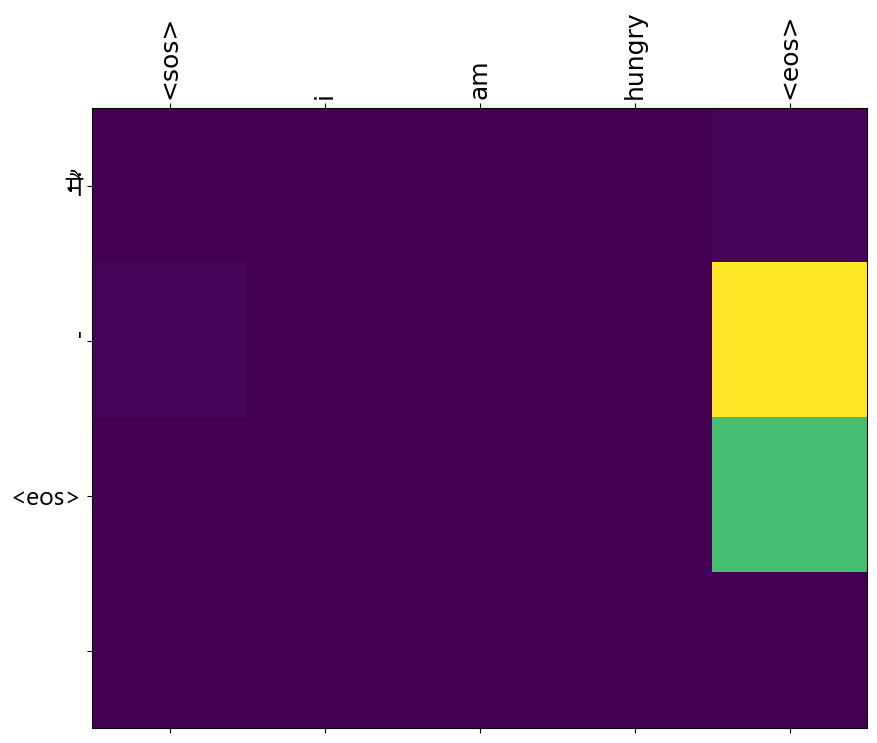

"मैं ' <eos> "

In [40]:
translate("I am hungry", True)

Input: <sos> i am hungry . can you give me something to eat . <eos>
Predicted translation: मैं तुम्हें पता है कि तुम एक ही नहीं है . <eos> 


/tmp/ipython-input-2811834746.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + sentence, fontdict=fontdict, rotation=90)
/tmp/ipython-input-2811834746.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + predicted_sentence, fontproperties=hindi_font, fontsize='18')


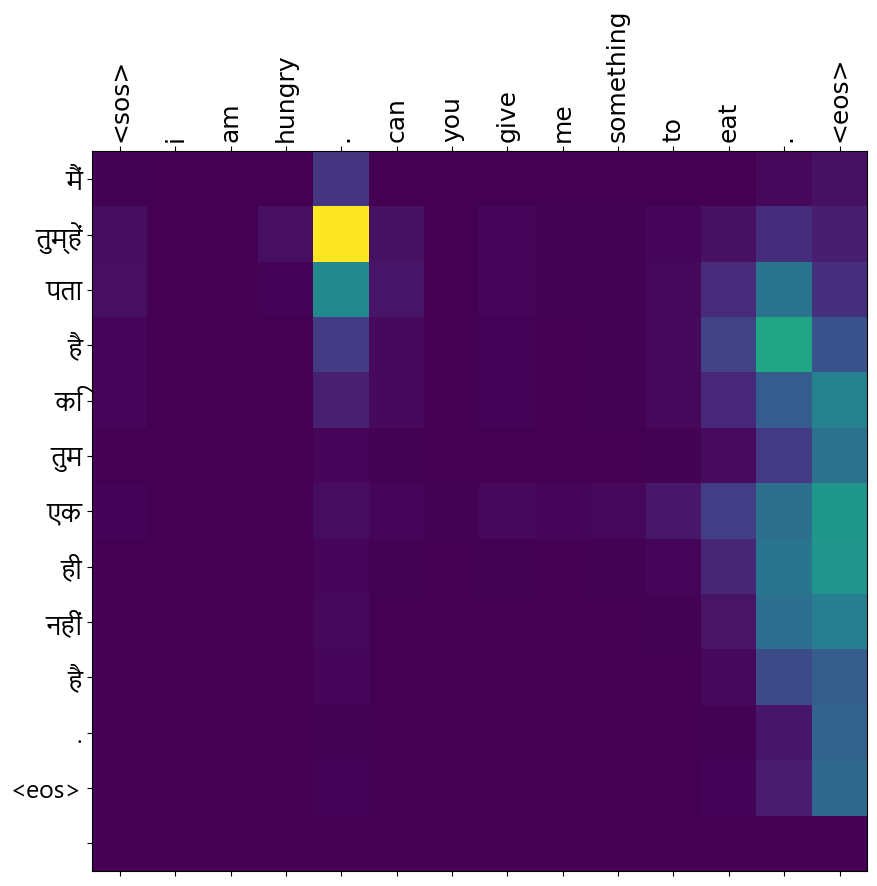

'मैं तुम्हें पता है कि तुम एक ही नहीं है . <eos> '

In [41]:
translate("I am hungry. Can you give me something to eat.", True)

In [42]:
# Load test data
test_input_sentences = []
test_output_sentences = []

# Read English test sentences
with open('test.en', encoding='utf-8') as f:
    for line in f:
        test_input_sentence = line.rstrip().strip("\n").strip('-')
        test_input_sentences.append(test_input_sentence)

# Read Hindi test sentences (reference translations)
with open('test.hi', encoding='utf-8') as f:
    for line in f:
        test_output_sentence = line.rstrip().strip("\n").strip('-')
        tokens = indic_tokenize.trivial_tokenize(test_output_sentence)
        test_output_sentences.append(['<sos>'] + tokens + ['<eos>'])

print(f"Number of test samples: {len(test_output_sentences)}")
print(f"\nExample (index 90):")
print(f"  English: {test_input_sentences[90]}")
print(f"  Hindi:   {test_output_sentences[90]}")

Number of test samples: 1000

Example (index 90):
  English: You're slower than molasses in January.
  Hindi:   ['<sos>', 'आप', 'जनवरी', 'में', 'गुड़', 'की', 'तुलना', 'में', 'धीमी', 'है', '.', '<eos>']


In [43]:
from nltk.translate.bleu_score import corpus_bleu
from nltk.translate.bleu_score import SmoothingFunction
chencherry = SmoothingFunction()
evaluate_n_sentences = 10

references = []
candidates = []
for i in range(evaluate_n_sentences):
  try:
    res = translate(test_input_sentences[i], False)
    ref = test_output_sentences[i].copy()
    ref = [e for e in ref if e not in ('<eos>', '<sos>', '.')]
    references.append(ref)
    listToStr = ' '.join(map(str, test_output_sentences[i]))
    print('Reference Translation: %s' % (listToStr))
    candidate = indic_tokenize.trivial_tokenize(res)
    candidate = [e for e in candidate if e not in ('<', 'eos','>', '.')]
    candidates.append(candidate)
  except:
    print('Sentence :', i+1, ' not translatable ..moving to next' )
score1 = corpus_bleu(references, candidates, smoothing_function=chencherry.method4)
score2 = corpus_bleu(references, candidates)
print('BLEU score on test data without smoothing function: ' ,score2)
print('BLEU score on test data with smoothing function: ' ,score1)

Input: <sos> prince ashitaka , are you steeled to gaze upon your fate ? <eos>
Predicted translation: एक बार , तुम एक एक एक राजा के लिए एक साथ कर रहे हैं ? <eos> 
Reference Translation: <sos> राजकुमार Ashitaka , आप अपने भाग्य पर टकटकी लोहे रहे हैं ? <eos>
Input: <sos> storm will be the closest man to him . <eos>
Predicted translation: एक बार एक ही काम है . <eos> 
Reference Translation: <sos> तूफान उसे निकटतम आदमी हो जाएगा . <eos>
Input: <sos> well , ilse , now you have to eat something , too . <eos>
Predicted translation: ठीक है , तुम , तुम एक ही नहीं है . <eos> 
Reference Translation: <sos> खैर , इल्से , अब तुम्हें भी कुछ खाना है . <eos>
Input: <sos> don t call me again , you jackass . <eos>
Predicted translation: आप , तुम आप से नहीं कर सकते हैं . <eos> 
Reference Translation: <sos> , तुम गधे मुझे फिर फोन नहीं है . <eos>
Input: <sos> your smile is saying it loudly , my dear . . . <eos>
Predicted translation: यह एक एक समय है , लेकिन यह है . . . <eos> 
Reference Translation: <sos> Your s

/usr/local/lib/python3.12/dist-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 2-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
/usr/local/lib/python3.12/dist-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 3-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
/usr/local/lib/python3.12/dist-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 4-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_

# **Prediction using Beam Search**

We extend the Decoder Prediction Model to use the Beam Search algorithm with a configurable value of the Beam Width (k)

In [44]:
def softmax(x):
    """Compute softmax values for each set of scores in x."""
    e_x = np.exp(x - np.max(x))
    return e_x / e_x.sum()


def reduce_mul(l):
    """Compute product of all elements in list."""
    out = 1.0
    for x in l:
        out *= x
    return out


def check_all_done(seqs):
    """Check if all sequences have reached <eos> token."""
    for seq in seqs:
        word = targ_lang.index_word.get(seq[-1][0], '<UNK>')
        if word != '<eos>':
            return False
    return True


def beam_search_step(dec_hid, enc_out, top_seqs, k):
    """
    Perform one step of beam search.

    Args:
        dec_hid: Decoder hidden state
        enc_out: Encoder outputs
        top_seqs: Current top-k sequences
        k: Beam width

    Returns:
        topk_seqs: Updated top-k sequences
        all_done: Whether all sequences have finished
        dec_hid: Updated decoder hidden state
        topk_scores: Scores of top-k sequences
    """
    all_seqs = []

    for seq in top_seqs:
        seq_score = reduce_mul([_score for _, _score in seq])

        # Check if sequence is complete
        word = targ_lang.index_word.get(seq[-1][0], '<UNK>')
        if word == '<eos>':
            all_seqs.append((seq, seq_score, True))
            continue

        # Get predictions for next token
        dec_input = tf.expand_dims([seq[-1][0]], 0)
        predictions, dec_hid, _ = decoder(dec_input, dec_hid, enc_out, training=False)

        # Get top-k predictions
        output_step = [(idx, prob) for idx, prob in enumerate(softmax(predictions[0].numpy()))]
        output_step = sorted(output_step, key=lambda x: x[1], reverse=True)

        for i, word in enumerate(output_step):
            if i >= k:
                break
            word_index = word[0]
            word_score = word[1]
            score = seq_score * word_score
            rs_seq = seq + [word]
            done = (word_index == targ_lang.word_index.get('<eos>', 2))
            all_seqs.append((rs_seq, score, done))

    # Sort by score and keep top-k
    all_seqs = sorted(all_seqs, key=lambda seq: seq[1], reverse=True)
    topk_seqs = [seq for seq, _, _ in all_seqs[:k]]
    topk_scores = [score for _, score, _ in all_seqs[:k]]
    all_done = check_all_done(topk_seqs)

    return topk_seqs, all_done, dec_hid, topk_scores


def evaluate_beam_search(sentence, beam_size=3):
    """
    Translate a sentence using beam search decoding.

    Args:
        sentence: Input sentence in source language
        beam_size: Number of beams to keep at each step

    Returns:
        result: List of top beam_size translations
        scores_seq: Scores for each translation
    """
    sentence = preprocess_sentence(sentence)

    # Convert words to indices, handling unknown words
    inputs = []
    for word in sentence.split(' '):
        if word in inp_lang.word_index:
            inputs.append(inp_lang.word_index[word])
        else:
            inputs.append(inp_lang.word_index.get('<UNK>', 1))

    inputs = tf.keras.preprocessing.sequence.pad_sequences(
        [inputs], maxlen=max_length_inp, padding='post'
    )
    inputs = tf.convert_to_tensor(inputs)

    # Encode
    hidden = encoder.initialize_hidden_state(batch_size=1)
    enc_out, enc_hidden = encoder(inputs, hidden, training=False)
    dec_hidden = enc_hidden

    # Initialize beam with <sos> token
    beam_seqs = [[(targ_lang.word_index['<sos>'], 1.0)]]

    # Beam search
    for _ in range(max_length_targ):
        beam_seqs, all_done, dec_hidden, scores_seq = beam_search_step(
            dec_hidden, enc_out, beam_seqs, beam_size
        )
        if all_done:
            break

    # Convert token IDs to words
    result = []
    for top_beam in beam_seqs:
        kresult = ''
        for pred_id, _ in top_beam:
            word = targ_lang.index_word.get(pred_id, '<UNK>')
            kresult += word + ' '
        result.append(kresult)

    return result, scores_seq

In [45]:
def translate_beam(sentence):
  result, score = evaluate_beam_search(sentence)
  return result, score

In [46]:
translate_beam("I am hungry.")

(['<sos> मैं इसे . <eos> ',
  '<sos> मैं इसे कर रहा है . . <eos> ',
  '<sos> मैं इसे कर दिया . <eos> '],
 [np.float32(0.00045664437),
  np.float32(0.00016354982),
  np.float32(0.00011629319)])

# *References*

1. The dataset is obtained from [here](http://lotus.kuee.kyoto-u.ac.jp/WAT/indic-multilingual/)

2. Refer the tensorflow tutorials available on NMT [here](https://tensorflow.org/tutorials/text/nmt_with_attention) and [here](https://www.tensorflow.org/addons/tutorials/networks_seq2seq_nmt) for examples on which this notebook is modelled.

3. Refer reference code and documentation available [here](https://github.com/prashanthi-r/Eng-Hin-Neural-Machine-Translation) which has been adopted

4. Indic Library documentation can be found [here](https://github.com/anoopkunchukuttan/indic_nlp_library/blob/master/docs/indicnlp.pdf)

5. Toy example for Beam Search adopted provided [here](https://gist.github.com/xylcbd/0abee09de5ca6a0364c4de2aa46ef90f)






